# Simple Linear Regression - California Housing Dataset

## Step 1: Import Required Libraries

We need to import essential libraries for data manipulation, visualization, and machine learning:
- **numpy**: For numerical operations
- **pandas**: For data manipulation and analysis
- **matplotlib**: For plotting and visualization
- **sklearn**: For machine learning algorithms and datasets

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

## Step 2: Load the Dataset

We'll use the California Housing dataset from sklearn. This dataset contains information about California housing districts with the goal of predicting the median house value.

**Steps:**
1. Fetch the dataset using `fetch_california_housing()`
2. Convert the data into a pandas DataFrame
3. Add the target variable (Price) as a new column
4. Display the first few rows to understand the data structure

In [29]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["Price"] = housing.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Data Exploration

Understanding the dataset structure and statistics is crucial before building any model.

**Steps:**
1. **df.shape**: Check the number of rows (samples) and columns (features)
2. **df.info()**: Get information about data types, non-null counts, and memory usage
3. **df.describe()**: View statistical summary (mean, std, min, max, quartiles) for each feature

This helps us understand:
- The size of our dataset
- Data types of each column
- Whether there are any missing values
- The range and distribution of each feature

In [30]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 4: Check for Missing Values

Missing values can significantly impact model performance. We need to identify and handle them appropriately.

**Steps:**
- Use `df.isnull().sum()` to count missing values in each column
- If missing values exist, we can either:
  - Drop rows with missing values
  - Impute missing values (mean, median, mode, or using ML algorithms)

In this dataset, we can see there are no missing values, so no action is needed.

In [31]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

## Step 5: Check for Duplicate Rows

Duplicate rows can bias our model by giving more weight to certain observations. We need to identify and remove them.

**Steps:**
- Use `df.duplicated().sum()` to count duplicate rows
- If duplicates exist, use `df.drop_duplicates()` to remove them

In this dataset, there are no duplicate rows, so no action is needed.

**Step 5: Duplicate checking**

## Step 6: Split Features and Target

We need to separate our data into:
- **X (Features)**: All columns except the target variable (Price)
- **y (Target)**: The variable we want to predict (Price)

**Steps:**
- Use `df.drop("Price", axis=1)` to get features (X)
- Use `df["Price"]` to get target (y)

This separation is essential for training our machine learning model.

In [32]:
df.duplicated().sum()

np.int64(0)

## Step 7: Data Visualization - Histograms

Visualizing the distribution of each feature helps us understand:
- The shape of the data (normal, skewed, etc.)
- Potential outliers
- Whether features need transformation

**Steps:**
- Use `df.hist()` to create histograms for all numerical features
- Set appropriate figure size and number of bins for better visualization

This helps identify which features might need scaling or transformation.

In [33]:
X = df.drop("Price",axis=1)

y = df["Price"]

## Step 8: Correlation Analysis

Understanding the relationships between features and the target variable helps in feature selection and understanding the data.

**Steps:**
1. Calculate correlation matrix using `df.corr()`
2. Sort correlations with the target variable (Price) to identify most important features
3. Create a heatmap visualization to easily see correlations

**Key Insights:**
- High positive correlation with Price means the feature increases house price
- High negative correlation means the feature decreases house price
- Features with low correlation might be less important for prediction

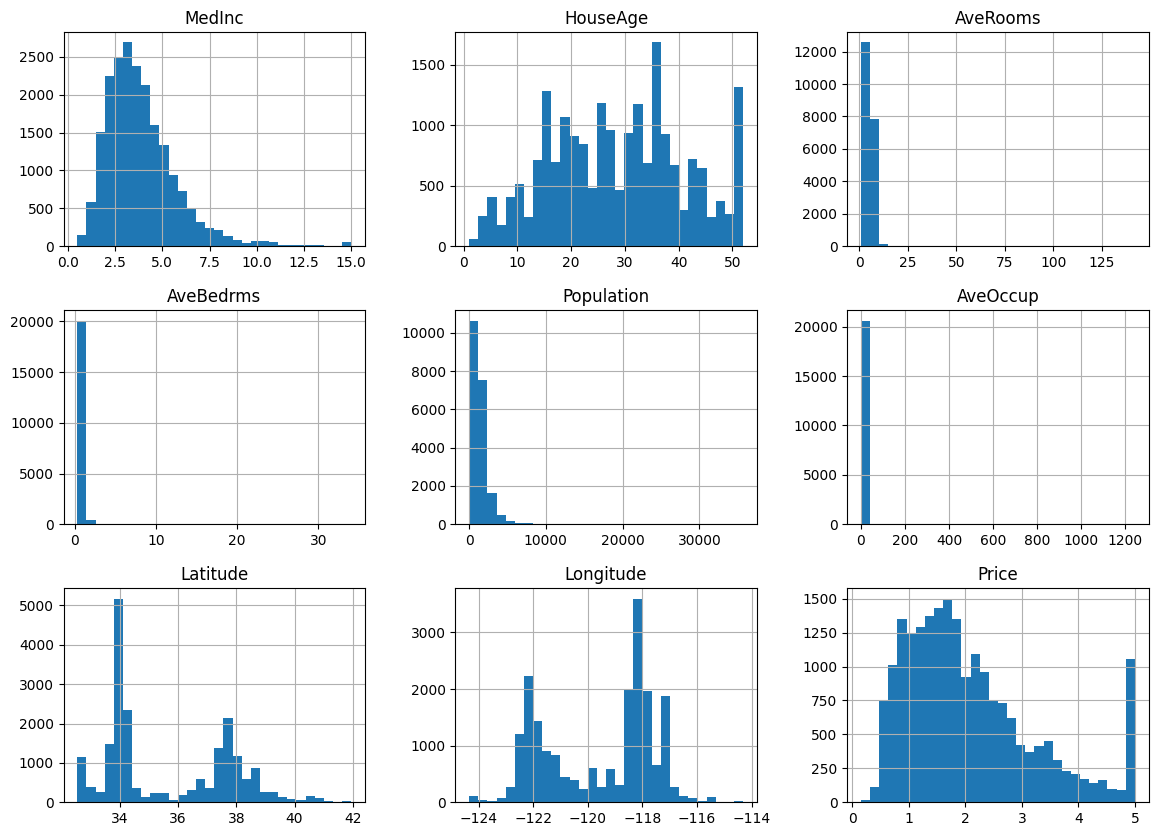

In [34]:
df.hist(
    figsize=(14,10),
    bins=30
)

plt.show()

## Step 9: Outlier Detection - Boxplots

Boxplots help identify outliers in each feature. Outliers can significantly affect model performance.

**Steps:**
- Create boxplots for each feature using `plt.boxplot()`
- Examine each plot for points outside the whiskers (potential outliers)

**Interpretation:**
- Points outside the whiskers are considered outliers
- We may need to handle outliers by:
  - Removing them (if they're errors)
  - Capping them (winsorization)
  - Using robust models that handle outliers well

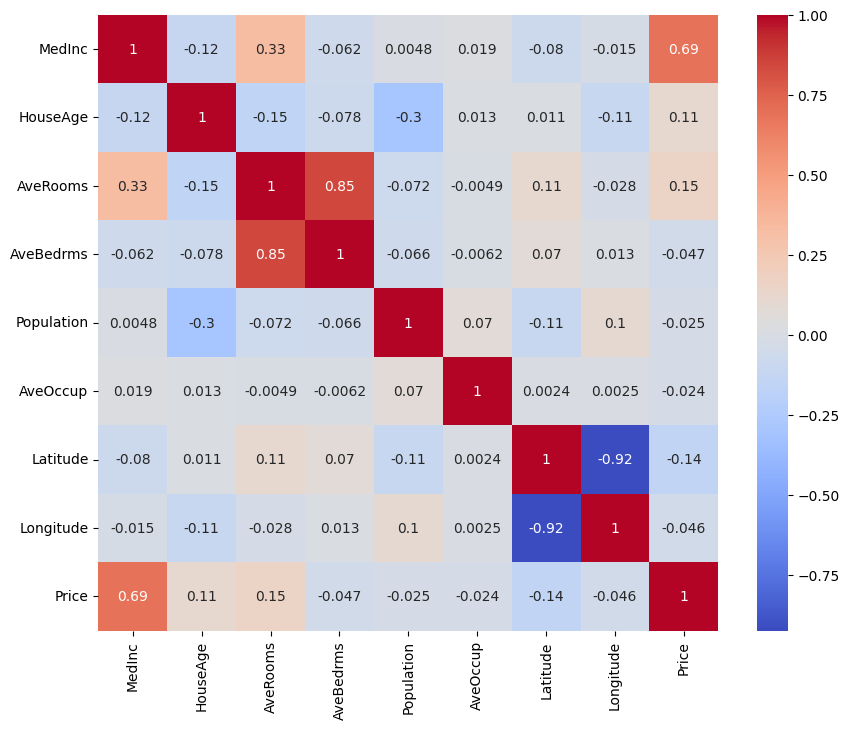

In [35]:
corr=df.corr()

corr["Price"].sort_values(
    ascending=False
)
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Step 10: Feature Scaling (Standardization)

Feature scaling is crucial for algorithms that use distance-based calculations or gradient descent. It ensures all features contribute equally to the model.

**Why Scale Features?**
- Features have different units and scales (e.g., MedInc in thousands, Latitude in degrees)
- Without scaling, features with larger values can dominate the model
- Helps convergence in gradient-based algorithms

**StandardScaler Formula:**
$$z = \frac{x - \mu}{\sigma}$$

Where:
- **z** = standardized value
- **x** = original value
- **μ** = mean of the feature
- **σ** = standard deviation of the feature

**Steps:**
1. Initialize StandardScaler
2. Fit and transform the features using `fit_transform()`
3. Convert back to DataFrame with original column names

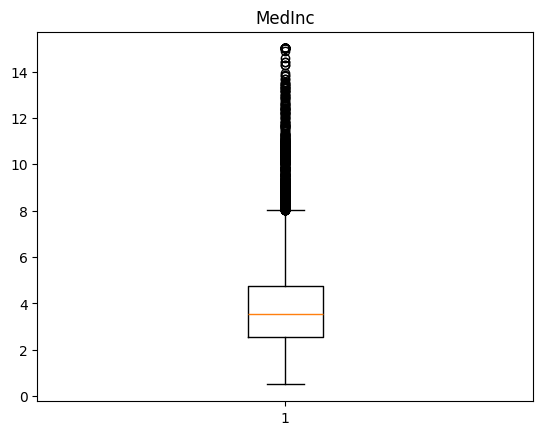

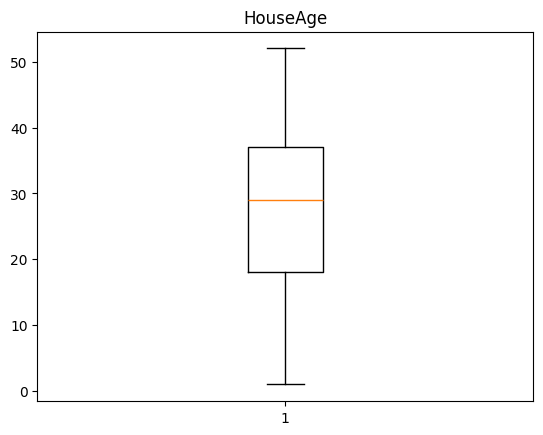

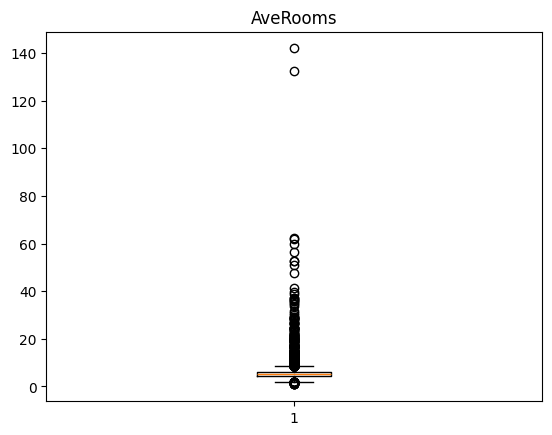

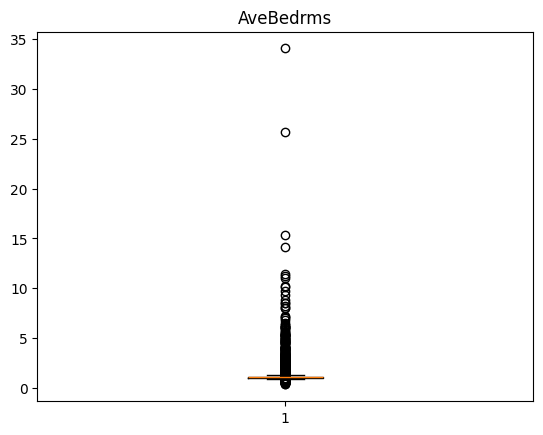

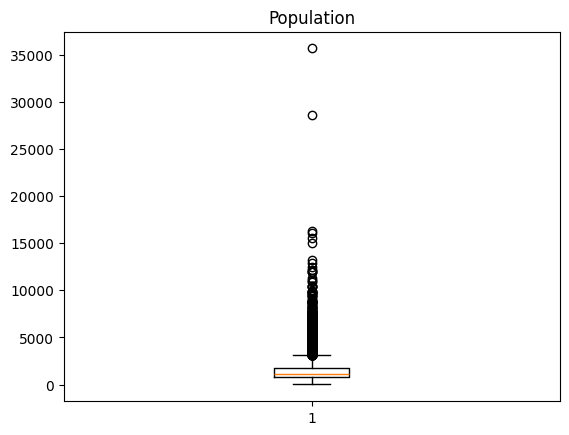

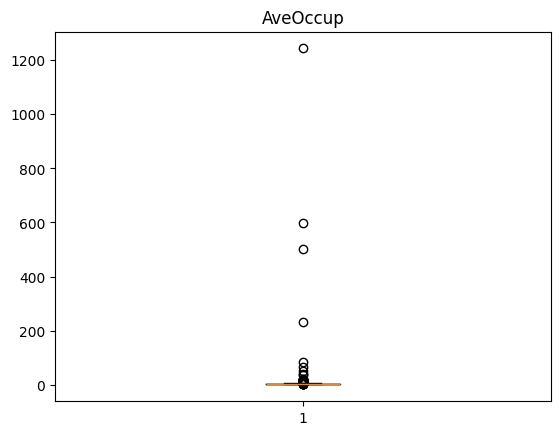

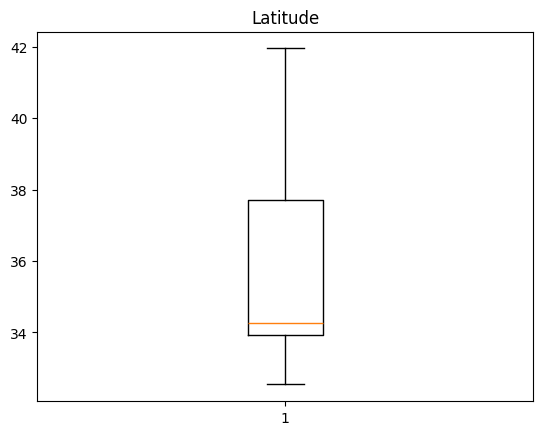

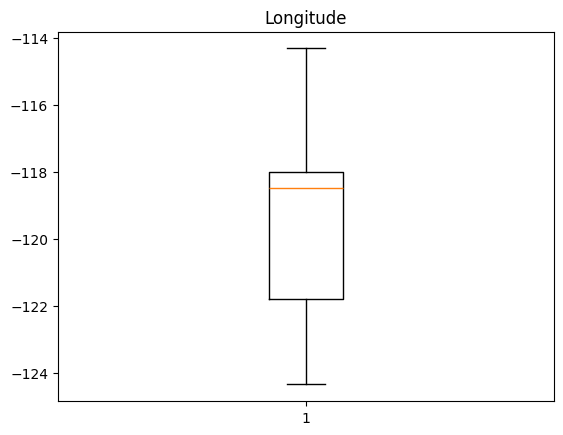

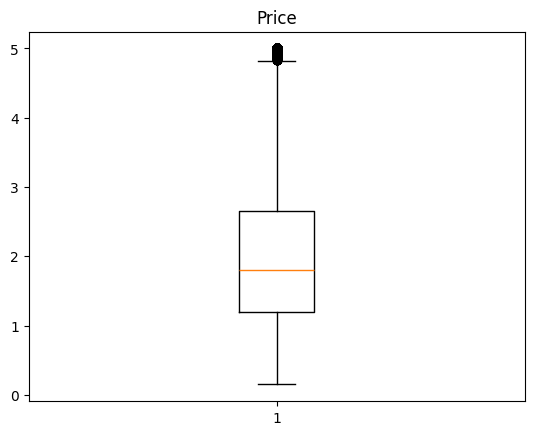

In [36]:
for col in df.columns:

    plt.figure()

    plt.boxplot(df[col])

    plt.title(col)

    plt.show()

## Step 11: Train-Test Split

Splitting the data into training and testing sets is essential to evaluate model performance on unseen data.

**Why Split?**
- Training set: Used to train the model (learn patterns)
- Testing set: Used to evaluate how well the model generalizes to new data
- Prevents overfitting and provides unbiased performance metrics

**Steps:**
1. Use `train_test_split()` to split the data
2. Set `test_size=0.2` (20% for testing, 80% for training)
3. Set `random_state=42` for reproducibility
4. Verify the shapes of train and test sets

**Common Splits:**
- 80-20 (default): Good balance for most datasets
- 70-30: When you have more data and want more for testing
- 90-10: When you have limited data and need more for training

In [37]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

X_scaled=pd.DataFrame(
    X_scaled,
    columns=X.columns
)

In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=\
train_test_split(
X_scaled,
y,
test_size=0.2,
random_state=42
)
X_train.shape
X_test.shape

(4128, 8)

## Simple Linear Regression Formula

**The Linear Regression Equation:**

$$y = \beta_0 + \beta_1 x + \epsilon$$

Where:
- **y** = dependent variable (target/price)
- **x** = independent variable (feature/MedInc)
- **β₀** = y-intercept (value of y when x = 0)
- **β₁** = slope (change in y for a one-unit change in x)
- **ε** = error term (residuals)

**Key Concepts:**
- The slope (β₁) indicates how much the house price changes for each unit increase in median income
- The intercept (β₀) is the predicted price when median income is zero
- The model assumes a linear relationship between the feature and target
- We use Ordinary Least Squares (OLS) to find the best-fitting line by minimizing the sum of squared residuals

In [39]:
X_train_simple = X_train[["MedInc"]]
X_test_simple = X_test[["MedInc"]]
print(X_train_simple.shape)
print(X_test_simple.shape)

(16512, 1)
(4128, 1)


In [40]:
from sklearn.linear_model import LinearRegression

simple_lr = LinearRegression()

simple_lr.fit(
    X_train_simple,
    y_train
)

LinearRegression()

## Model Coefficients Interpretation

- **Slope (β₁)**: Represents the change in house price for a one-unit increase in median income
- **Intercept (β₀)**: Represents the predicted house price when median income is zero (theoretical baseline)

These coefficients are learned by minimizing the sum of squared residuals:

In [41]:
y_pred = simple_lr.predict(
    X_test_simple
)

## Model Evaluation Metrics

- **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values
- **MSE (Mean Squared Error)**: Average of squared differences (penalizes larger errors more)
- **RMSE (Root Mean Squared Error)**: Square root of MSE (in same units as target variable)
- **R² (R-squared)**: Proportion of variance in target explained by the model (0 to 1)

**R² Formula:**
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

In [42]:
print("Slope:",simple_lr.coef_[0])

print("Intercept:",simple_lr.intercept_)

Slope: 0.7966490785832865
Intercept: 2.0677186405797796


In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse**0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R²:",r2)

MAE: 0.629908653009376
MSE: 0.7091157771765549
RMSE: 0.8420901241414455
R²: 0.45885918903846656


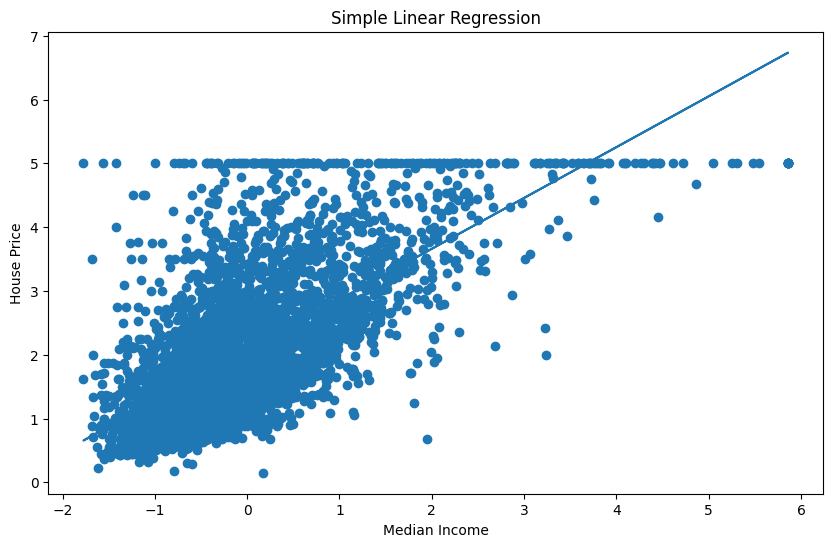

In [44]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_test_simple,
    y_test
)

plt.plot(
    X_test_simple,
    y_pred
)

plt.xlabel("Median Income")

plt.ylabel("House Price")

plt.title(
    "Simple Linear Regression"
)

plt.show()

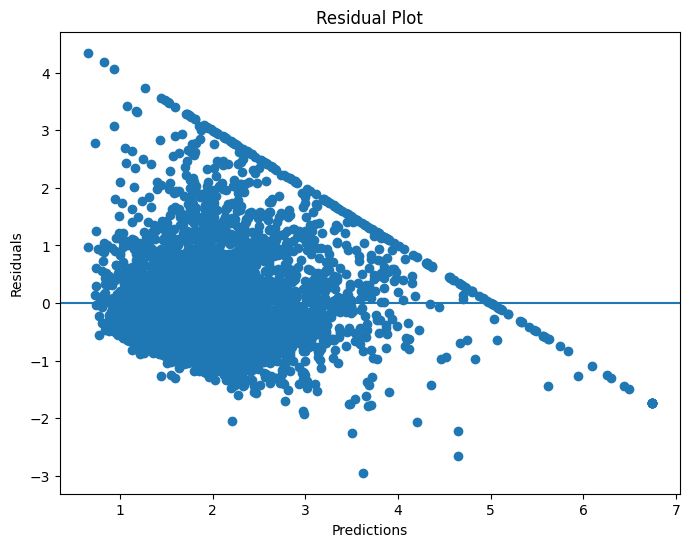

In [45]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(y=0)

plt.xlabel("Predictions")

plt.ylabel("Residuals")

plt.title(
    "Residual Plot"
)

plt.show()

In [48]:
results=[]

results.append({

    "Model":"Simple Linear Regression",

    "MAE":mae,

    "RMSE":rmse,

    "R2":r2
})
pd.DataFrame(results)

,Model,MAE,RMSE,R2
0,Simple Linear Regression,0.629909,0.84209,0.458859
